## Importing Libraries ##

In [15]:
import pandas as pd

In [ ]:
Loading Datasets

In [3]:
trades = pd.read_csv('historical_data.csv')

In [4]:
fear = pd.read_csv('fear_greed_index.csv')

## Understanding Data ##

### Inspecting first few rows ###

In [10]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### Checking shape of the dataset

In [16]:
trades.shape

(211224, 16)

In [17]:
fear.shape

(2644, 4)

### Checking names of columns

In [19]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [20]:
fear.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

### Check for missing Values

In [21]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [22]:
fear.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

### Check for duplicate records

In [23]:
trades.duplicated().sum()

np.int64(0)

In [24]:
fear.duplicated().sum()

np.int64(0)

In [33]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [32]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

In [28]:
fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [27]:
fear['date'] = pd.to_datetime(fear['date'])

### Creating Date Column for Merging

In [72]:
#Extracting only the date part from Timestamp IST

trades['date'] = trades['Timestamp IST'].dt.date

In [35]:
trades['date'] = pd.to_datetime(trades['date'])

In [36]:
trades[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


### Merging both the datasets

In [37]:
merged = pd.merge(
    trades,
    fear[['date', 'classification']],
    on='date',
    how='inner'
)

In [39]:
merged.shape

(211218, 18)

In [71]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,Win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,False


#### Number of Trades Under Each Sentiment

In [42]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

#### Average Profit

In [43]:
merged.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

#### Total Profit

In [44]:
merged.groupby('classification')['Closed PnL'].sum()

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64

In [45]:
merged['Win'] = merged['Closed PnL'] > 0

#### Percentage of trades that were profitable under each sentiment

In [46]:
win_rate = merged.groupby('classification')['Win'].mean() * 100
win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

In [47]:
pd.crosstab(
    merged['classification'],
    merged['Direction']
)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


#### which trade perfomed better under each sentiment?

In [48]:
merged.groupby(
    ['classification', 'Direction']
)['Closed PnL'].mean()

classification  Direction                
Extreme Fear    Buy                              0.000000
                Close Long                      81.197371
                Close Short                    123.400238
                Long > Short                     1.331956
                Open Long                        0.000000
                Open Short                       0.000000
                Sell                          -135.021730
                Short > Long                 -1932.516940
                Spot Dust Conversion             0.000000
Extreme Greed   Buy                              0.000000
                Close Long                      61.830783
                Close Short                     28.970490
                Long > Short                   120.600968
                Open Long                        0.000000
                Open Short                       0.000000
                Sell                           290.572354
                Short > Long  

#### trading volume by sentiment.

In [49]:
merged.groupby('classification')['Size USD'].sum()

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64

#### Top traded coins for each sentiment

In [52]:
top_coin = (
    merged.groupby(['classification', 'Coin'])
    .size()
    .reset_index(name='Trade_Count')
)

top_coin.loc[
    top_coin.groupby('classification')['Trade_Count'].idxmax()
]

,classification,Coin,Trade_Count
41,Extreme Fear,HYPE,10278
88,Extreme Greed,@107,10403
324,Fear,HYPE,27951
387,Greed,@107,8398
645,Neutral,HYPE,17324


### Visualization

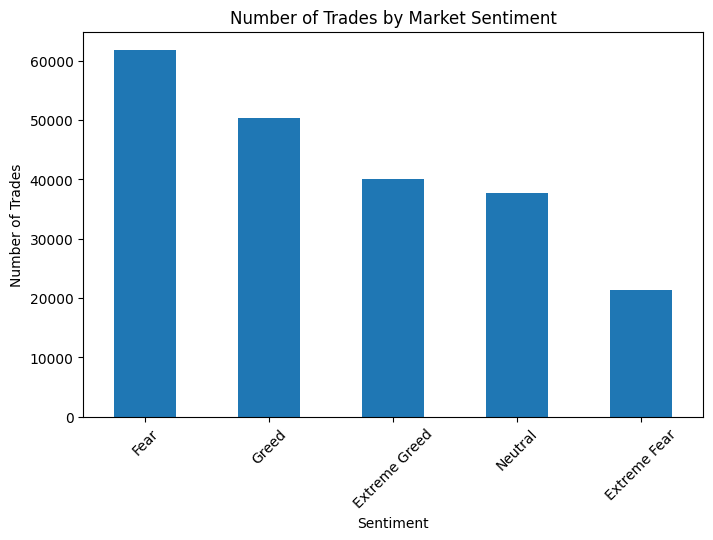

In [54]:
import matplotlib.pyplot as plt

trade_counts = merged['classification'].value_counts()
trade_counts.plot(kind='bar',figsize=(8,5))

plt.title('Number of Trades by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.show()

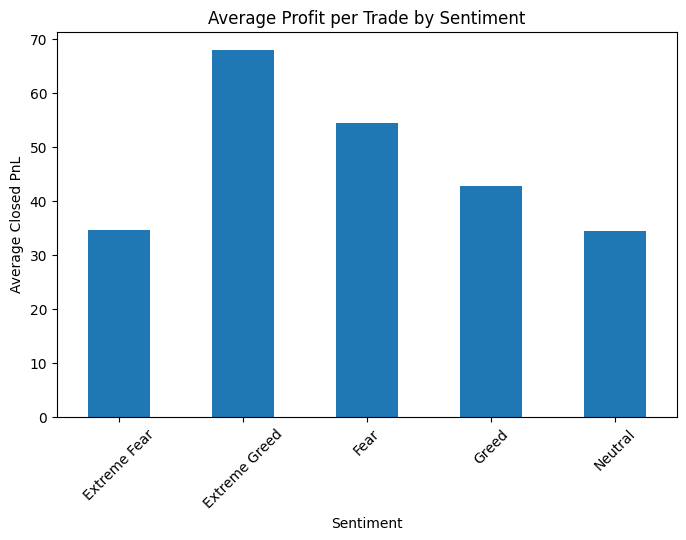

In [64]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean()
avg_pnl.plot(kind='bar',figsize=(8,5))

plt.title('Average Profit per Trade by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=45)
plt.show()

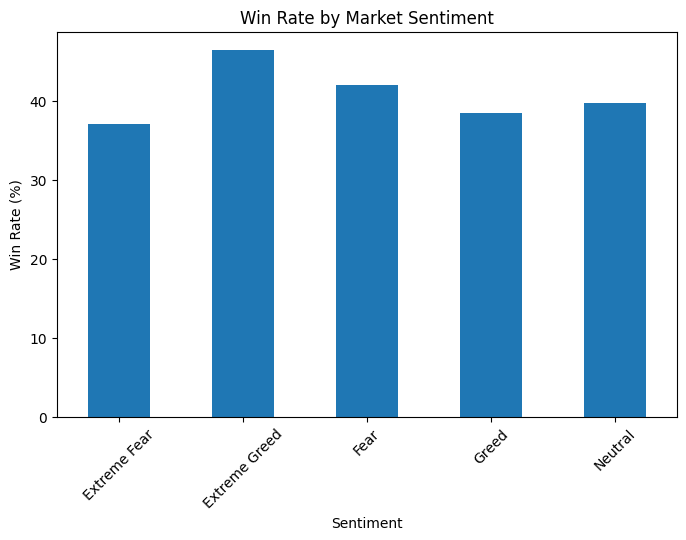

In [66]:
win_rate = merged.groupby('classification')['Win'].mean()*100
win_rate.plot(kind='bar',figsize=(8,5))
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=45)
plt.show()

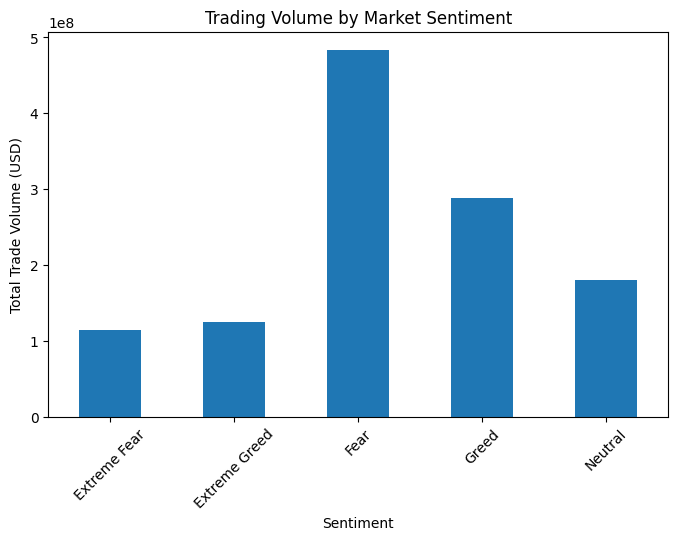

In [70]:
volume = merged.groupby('classification')['Size USD'].sum()
volume.plot(kind='bar',figsize=(8,5))

plt.title('Trading Volume by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Total Trade Volume (USD)')
plt.xticks(rotation=45)
plt.show()

### Key Findings

1. Fear had the highest number of trades.
2. Fear generated the highest trading volume.
3. Fear generated the highest total profit.
4. Extreme Greed had the highest average profit per trade.
5. Extreme Greed had the highest win rate.
6. Extreme Fear had the lowest win rate.
7. Short positions performed better during Fear and Extreme Fear.
8. Long positions performed better during Greed and Extreme Greed.
9. HYPE dominated trading activity during Fear, Extreme Fear and Neutral periods.
10. @107 dominated trading activity during Greed and Extreme Greed periods.